In [ ]:
from dotenv import load_dotenv
import os
load_dotenv()

GoogleGeminiKey = os.getenv('GOOGLE_GEMINI_KEY')
connection = os.getenv("PG_CONNECTION_STRING")

In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_postgres.vectorstores import PGVector

raw_documents = TextLoader("data/how_to_read_pnl.txt").load()
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200)
documents = text_splitter.split_documents(raw_documents)

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/embedding-001", google_api_key=GoogleGeminiKey)
db = PGVector.from_documents(documents, embeddings, connection=connection)

In [ ]:
# create retriever
retriever = db.as_retriever(search_kwargs={"k": 10})

# fetch relevant documents.
docs = retriever.invoke("how to read pnl?")
docs

[Document(id='4c7a2f4d-0912-46ae-816b-744c83117aac', metadata={'source': 'data/how_to_read_pnl.txt'}, page_content='Tata McGraw Hill Publishing Company Limited\nNEW DELHI\nN. Ramachandran\nPrincipal Consultant\nManagement Advisory Services\nKochi\nRam Kumar Kakani\nAssociate Professor, XLRI\nJamshedpur\nHow to Read\nA\nPROFIT AND LOSS\nSTATEMENT\nTata McGraw Hill Professional: Finance Made Easy Series\nPublished by Tata McGraw Hill Education Private Limited,\n7 West Patel Nagar, New Delhi 110 008.\nCopyright © 2010, by Tata McGraw Hill Education Private Limited\nNo part of this publication may be reproduced or distributed in any form or by any\nmeans, electronic, mechanical, photocopying, recording, or otherwise or stored in a\ndatabase or retrieval system without the prior written permission of the publishers. The\nprogram listings (if any) may be entered, stored and executed in a computer system,\nbut they may not be reproduced for publication.\nThis edition can be exported from Indi

In [ ]:
from langchain_google_genai import GoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from IPython.display import Markdown, display

llm = GoogleGenerativeAI(model="gemini-2.0-flash-001",
                         api_key=GoogleGeminiKey, temperature=0)

prompt_template = ChatPromptTemplate.from_messages(
    [("system", """
            Answer the question on the based on the given context below. If the question cannot be answered using the information
provided in the context, respond with "I don't know".
    """),
     ("system", "Answer always in markdown format and List the items."),
     ("human", "Context: {context}"),
     ("human", "Question: {question}")])

chain = prompt_template | llm

query = "how to read pnl?"

docs = retriever.get_relevant_documents(query)

result = chain.invoke({"context": docs, "question": query})

display(Markdown(result))

C:\Users\jeetc\AppData\Local\Temp\ipykernel_9756\2773577904.py:20: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = retriever.get_relevant_documents(query)


Here are key points on how to read a Profit and Loss (P&L) statement, based on the provided context:

*   **Non-Operating Income:** This comes from activities not part of the core business.

*   **Profit After Tax (PAT) or Net Profit:** This is the net income after deducting tax from Profit Before Tax (PBT). It measures net earnings available to the company's shareholders.

*   **Profit Available for Distribution:** This is calculated by summing PAT and retained earnings from previous years.

*   **Contents of Profit and Loss Account (Flow Chart):**
    1.  Sales (or revenues)
    2.  Less: Cost of goods sold
    3.  Gross profit
    4.  Less: Operating expenses
    5.  Operating profit
    6.  Less: Non-operating expenses
    7.  Profit before interest and tax (PBIT)
    8.  Less: Interest
    9.  Profit before tax (PBT)
    10. Less: Tax
    11. Profit after tax (PAT)
    12. Add: Previous year’s balance of P&L A/C
    13. Profit available for distribution
    14. Less: Appropriations
    15. Retained earnings

In [ ]:
from langchain_core.runnables import chain


@chain
def chat(input):
    # fetch relevant documents
    docs = retriever.get_relevant_documents(input)

    # formatted prompt
    formatted = prompt_template.invoke({"context": docs, "question": input})

    # generate response
    answer = llm.invoke(formatted)

    return {"answer": answer, "docs": docs}


chat.invoke(query)

{'answer': "Here are key points on how to read a Profit and Loss (P&L) statement, based on the provided context:\n\n*   **Non-Operating Income:** This comes from activities not part of the core business.\n\n*   **Profit After Tax (PAT) or Net Profit:** This is the net income after deducting tax from Profit Before Tax (PBT). It measures net earnings available to the company's shareholders.\n\n*   **Profit Available for Distribution:** This is calculated by summing PAT and retained earnings from previous years.\n\n*   **Contents of Profit and Loss Account (Flow Chart):**\n    1.  Sales (or revenues)\n    2.  Less: Cost of goods sold\n    3.  Gross profit\n    4.  Less: Operating expenses\n    5.  Operating profit\n    6.  Less: Non-operating expenses\n    7.  Profit before interest and tax (PBIT)\n    8.  Less: Interest\n    9.  Profit before tax (PBT)\n    10. Less: Tax\n    11. Profit after tax (PAT)\n    12. Add: Previous year’s balance of P&L A/C\n    13. Profit available for distrib

#### $ Problems of to make production ready robust RAG chat application.

1. How do we handle the variability in the quality of a user input.
2. How do we route queries to retrieve relevant data from a variety of data sources.
3. How do we transform natural language to the query language of the target data source?
4. How do we optimize out indexing process ie embedding text splitting?


#### Query Transformation can solve the first problem.

### Rewrite-Retrieve-Read


In [33]:
query = """
Today I woke up and realized that my laptop battery was low.then I found a charger in the kitchen but it wasn't working properly.
So I decided to ask for help from my friend who is an engineer. How to read PnL?
"""

res = chat.invoke(query)
print(res['answer'], res['docs'])

I don't know. [Document(id='46fda176-7371-4384-acda-9b85b009634c', metadata={'source': 'data/how_to_read_pnl.txt'}, page_content='How to Read\nA\nPROFIT AND LOSS\nSTATEMENT\nTata McGraw Hill Professional: Finance Made Easy Series\nTata McGraw Hill Professional: Finance Made Easy Series\nFinancial success is the raison d’être of any business, and fi nancial health\nof any organization is refl ected in its fi nancial statements. But, it has been\nobserved that managerial professionals often have little understanding of\nfi nance and little time to read treatises on it. Further, fi nancial statements\nare regarded as too complex to understand and left to be ‘deciphered’ by\nfi nance experts. Hence, cultivating a culture of awareness and transparency\nof fi nance is a prime imperative.\nFinance Made Easy Series has been designed to impart management\nexecutives with adequate knowledge to understand and appreciate fi nancial\nstatements and their implications for the fi scal solvency of the

In [ ]:
rewrite_prompt = ChatPromptTemplate.from_template(
    """
    Provide a better search query for web search engine to answer the question below,
    end the queries with "**". 
    Question: {question}
    Answer:
    """
)


def parse_rewrite_output(message):
    return message.split('**')[0]


rewrite = rewrite_prompt | llm | parse_rewrite_output

# rewrite.invoke(query)


@chain
def chat_rrr(query):
    rrr_query = rewrite.invoke(query)
    return chat.invoke(rrr_query)


res = chat_rrr.invoke(query)
print(res['answer'], res['docs'])

Here are key points about understanding a Profit and Loss (P&L) statement for beginners, based on the provided context:

*   **Purpose**: A P&L statement, also known as an Income Statement, summarizes a company's revenues and expenses over a specific period to determine its profit or loss.

*   **Importance**: It reflects the financial health of a company and helps stakeholders understand the profitability, compare performance over time, and predict future profits.

*   **Basic Calculation**: The basic formula is Revenues - Expenses = Profit (if revenues exceed expenses) or Loss (if expenses exceed revenues).

*   **Key Components**:
    *   **Revenue**: The income generated from sales of goods or services.
    *   **Cost of Goods Sold**: Direct costs associated with producing goods or delivering services.
    *   **Gross Profit**: Revenue minus the cost of goods sold.
    *   **Operating Expenses**: Expenses incurred during normal business operations (e.g., personnel, depreciation).
 

In [ ]:
@chain
def chat_rrr(query):
    new_query = rewrite.invoke(query)

    docs = retriever.get_relevant_documents(new_query)

    formatted_docs = prompt_template.invoke(
        {"question": new_query, "context": docs})

    return llm.invoke(formatted_docs)


print(query)
print(chat_rrr.invoke(query))


Today I woke up and realized that my laptop battery was low.then I found a charger in the kitchen but it wasn't working properly.
So I decided to ask for help from my friend who is an engineer. How to read PnL?

I don't know


#### Multi-Query Retrieval to capture full scope of information required to answer the query.


In [ ]:
from langchain.prompts import ChatPromptTemplate

perspectives_prompt = ChatPromptTemplate.from_template("""
                    You are an AI language model assistant. Your task is to generate five different version of the given question,
                    to retrieve relevant document from a vector database.By generating multiple perspectives of the user question,
                    your goal is to help the user overcome of the limitations of the distance-based similarity search in vector databases.
                    Provide these alternative questions separated by newlines DO NOT INCLUDE ANY OTHER TEXT just 5 similar queries only separated by \n. Original question: {question}
                   """)


def parse_queries_output(message):
    return message.split("\n")


query_gen = perspectives_prompt | llm | parse_queries_output

In [ ]:
def get_unique_union(documents_list):
    # flatten the list and dedupe them
    deduped_docs = {
        doc.page_content: doc for sublist in documents_list for doc in sublist
    }

    return list(deduped_docs.values())


retrieval_chain = query_gen | retriever.batch | get_unique_union

NameError: name 'retriever' is not defined

In [ ]:
# logger chain

@chain
def retrieval_chain_with_logger(question):
    raw_queries = query_gen.invoke(question)
    print(f"Generated queries: {raw_queries}")
    docs = retriever.batch(raw_queries)
    print(f"Retrieved documents: {docs}")

    summarized_docs = get_unique_union(docs)
    print(f"Unique documents: {summarized_docs}")

    return summarized_docs

In [ ]:
prompt = ChatPromptTemplate.from_template("""
Answer the following question based on provided context:
{context}
Question: {question}
""")


@chain
def multi_query_retrieval(question):
    # docs = retrieval_chain.invoke(question)
    docs = retrieval_chain_with_logger.invoke(question)

    formatted = prompt.invoke({"context": docs, "question": question})

    answer = llm.invoke(formatted)

    return {"answer": answer, "source_documents": docs}


complete_answer = multi_query_retrieval.invoke(
    "How to read the Profit and loss statement?")

print(complete_answer["answer"])
print(complete_answer["source_documents"])

Generated queries: ['What are the key components of a profit and loss statement and how do I interpret them?', "How can I analyze a company's financial performance using its income statement?", 'What are the common line items in a P&L statement and what do they tell me about a business?', 'Explain the process of understanding and interpreting a profit and loss statement.', 'What are some important ratios and metrics derived from the P&L statement and how are they calculated?']
Retrieved documents: [[Document(id='d936cd35-7dc8-4fc5-a811-1f67742a3f21', metadata={'source': 'data/how_to_read_pnl.txt'}, page_content='50 How to Read a Profi t and Loss Statement\nform part of the balance sheet). In Box 5.1, we uncover the essence of the\nrequirement of the income statement again.\nBox 5.1 Need for An Income Statement\nNormally, most of the events and transactions aff ect the assets\nand/or liabilities and hence aff ect the balance sheet. A change\nin the owner(s)’ equity can either be brought

<b> Small Exercise/Experiment </b>

<li> function to add document in db </li>
<li> query experiment </li>
<li> markdown into query </li>


In [ ]:
from langchain.indexes import SQLRecordManager, index
from langchain.docstore.document import Document
from langchain.embeddings.base import Embeddings
from langchain.text_splitter import RecursiveCharacterTextSplitter
from typing import List
from langchain_community.document_loaders import PyMuPDFLoader
from uuid import uuid4
from langchain_postgres.vectorstores import PGVector


class RAGIndexer:
    def __init__(
        self,
        connection_string: str,
        embedding_model: Embeddings,
        user_id: str,
        mode: str = "private",
        base_collection: str = "rag_docs",
        use_jsonb: bool = True,
        source_key: str = "source"
    ):
        assert mode in ["private",
                        "public"], "mode must be 'private' or 'public'"

        self.user_id = user_id
        self.mode = mode
        self.connection_string = connection_string
        self.embedding_model = embedding_model
        self.use_jsonb = use_jsonb
        self.source_key = source_key
        self.loader = None

        # Namespacing
        self.collection_name = f"{base_collection}_{user_id}" if mode == "private" else f"{base_collection}_public"
        self.namespace = f"{base_collection}_{user_id}" if mode == "private" else f"{base_collection}_public"

        # Record manager
        # self.record_manager = SQLRecordManager(namespace=self.namespace, db_url=connection_string)
        # self.record_manager.create_schema()

        # Vector store
        self.vector_store = PGVector(
            collection_name=self.collection_name,
            embeddings=self.embedding_model,
            connection=connection_string,
            use_jsonb=use_jsonb
        )

        self._doc_filter = lambda x: bool(
            x.page_content and x.page_content.strip())

    def _add_metadata(self, doc: Document, visibility: str = "private") -> Document:
        metadata = doc.metadata or {}
        metadata["owner"] = self.user_id
        metadata["visibility"] = visibility
        doc.metadata = metadata
        return doc

    def _chunking(self, docs: List[Document]) -> List[Document]:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=1000, chunk_overlap=200)
        return splitter.split_documents(self.documents)

    def load_pdf(self, path):
        if os.path.exists(path):
            print(f"Loading PDF from {path}")
            self.loader = PyMuPDFLoader(path)
            self.documents = self.loader.load()
        else:
            print("File not found at path", path)
            raise FileNotFoundError(f"File not found at {path}")

    def add_documents(self, isFilter: bool = True, isChunking: bool = True):
        if not self.documents:
            print("Documents are not loaded")
        else:
            if isFilter:
                docs = [doc for doc in self.documents if self._doc_filter(doc)]
            else:
                docs = self.documents

            if isChunking:
                docs = self._chunking(docs)

            ids = [str(uuid4()) for _ in range(len(docs))]
            outIds = self.vector_store.add_documents(docs, ids=ids)
            print("Documents are added successfully")
            return outIds
        
    def add

    # def add_documents(
    #     self,
    #     docs: List[Document],
    #     visibility: str = "private",
    #     source_id_key: str = "source"
    # ):
    #     enriched_docs = [self._add_metadata(doc, visibility) for doc in docs]
    #     chunked_docs = self._chunking(enriched_docs)

    #     return index(
    #         docs=chunked_docs,
    #         record_manager=self.record_manager,
    #         vector_store=self.vector_store,
    #         cleanup="incremental",
    #         source_id_key=source_id_key
    #     )

    def delete_documents_by_source_ids(self, source_ids: List[str]):
        for source_id in source_ids:
            self.record_manager.delete_keys([source_id])
            self.vector_store.delete(source_id)

    def search(
        self,
        query: str,
        k: int = 5,
        allow_public: bool = True
    ) -> List[Document]:
        results = self.vector_store.similarity_search(query, k=k)

        if allow_public and self.mode != "public":
            public_vs = PGVector.from_existing_index(
                collection_name="rag_docs_public",
                embedding=self.embedding_model,
                connection=self.connection_string,
                use_jsonb=self.use_jsonb
            )
            results.extend(public_vs.similarity_search(query, k=k))

        return results

    def get_vector_store(self):
        return self.vector_store

    def get_record_manager(self):
        return self.record_manager

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain.docstore.document import Document

embedding_model = GoogleGenerativeAIEmbeddings(
    model="models/embedding-001", google_api_key=GoogleGeminiKey)

indexer = RAGIndexer(
    connection_string=connection,
    embedding_model=embedding_model,
    user_id="diljit_647",
    mode="private"
)

indexer.load_pdf("data/pocket book of economic indicator.pdf")
indexer.add_documents(True, True)

indexer.search("What are the key economic indicators?")

Loading PDF from data/pocket book of economic indicator.pdf
Documents are added successfully


[Document(id='bf59b0a6-efe5-42da-96de-bc5ace08920b', metadata={'page': 3, 'title': 'Introduction', 'author': 'Windows', 'format': 'PDF 1.4', 'source': 'data/pocket book of economic indicator.pdf', 'creator': 'Acrobat PDFMaker 5.0 for Word', 'modDate': "D:20021015205143-05'00'", 'moddate': '2002-10-15T20:51:43-05:00', 'subject': '', 'trapped': '', 'keywords': '', 'producer': 'Acrobat Distiller 5.0 (Windows)', 'file_path': 'data/pocket book of economic indicator.pdf', 'encryption': 'Standard V1 R2 40-bit RC4', 'total_pages': 39, 'creationDate': "D:20020926220432-05'00'", 'creationdate': '2002-09-26T22:04:32-05:00'}, page_content='The Pocketbook Of Economic Indicators \n \n \n_________________________________________________________________________ \n \n \nIntroduction \n \nIf you have no idea what CPI, PMI, or ECI mean, then you are like most beginning \ninvestors. Let me explain these and a few others terms to enhance your knowledge \nof indicators that affect your investments. \n \nEco

In [ ]:
indexer = RAGIndexer(
    connection_string=connection,
    embedding_model=embedding_model,
    user_id="diljit_647",
    mode="public"
)

indexer.load_pdf("data/how to read balacesheet.pdf")
indexer.add_documents(True, True)

indexer.search("What are the key economic indicators?")

Loading PDF from data/how to read balacesheet.pdf
Documents are added successfully


[Document(id='cbdcae83-61d4-4c7e-8c3c-aa1bd5443ee5', metadata={'page': 27, 'title': '', 'author': '', 'format': 'PDF 1.4', 'source': 'data/how to read balacesheet.pdf', 'creator': '', 'modDate': 'D:20200424223818Z', 'moddate': '2020-04-24T22:38:18+00:00', 'subject': '', 'trapped': '', 'keywords': '', 'producer': 'PDFTron PDFNet, V7.10742', 'file_path': 'data/how to read balacesheet.pdf', 'total_pages': 87, 'creationDate': 'D:20110627140600Z', 'creationdate': '2011-06-27T14:06:00+00:00'}, page_content='sheet.\nEmployees: The employees \nare interested in knowing \nthe proﬁ t ﬁ gures and \ngrowth of the company. \nTheir incentives and \npromotions are dependent \non these ﬁ gures.\nSuppliers: The \nsuppliers look forward \nto developing healthy, \nlong-term relations with \nﬁ nancially viable and \nhealthy companies.\nUSERS'),
 Document(id='25470a2e-5d36-482b-a2ae-0b1cf1842949', metadata={'page': 82, 'title': '', 'author': '', 'format': 'PDF 1.4', 'source': 'data/how to read balacesheet.

In [ ]:
indexer_public = RAGIndexer(
    connection_string=connection,
    embedding_model=embedding_model,
    user_id="diljit_647",
    mode="public"
)

indexer_public.load_pdf(
    "data/The New Trading for a Living_ Psychology, Discipline, Trading Tools and Systems, Risk Control, Trade Management (Wiley Trading) ( PDFDrive ).pdf")
indexer_public.add_documents(True, True)

indexer_public.search("What are the key economic indicators?")

Loading PDF from data/The New Trading for a Living_ Psychology, Discipline, Trading Tools and Systems, Risk Control, Trade Management (Wiley Trading) ( PDFDrive ).pdf
Documents are added successfully


[Document(id='54dc4228-3233-478b-be6a-d827328dda1f', metadata={'page': 88, 'title': 'The New Trading for a Living', 'author': 'Alexander Elder', 'format': 'PDF 1.7', 'source': 'data/The New Trading for a Living_ Psychology, Discipline, Trading Tools and Systems, Risk Control, Trade Management (Wiley Trading) ( PDFDrive ).pdf', 'creator': 'Adobe InDesign CC 2014 (Macintosh)', 'modDate': "D:20141007171232+01'00'", 'moddate': '2014-10-07T17:12:32+01:00', 'subject': '', 'trapped': '', 'keywords': '', 'producer': 'Adobe PDF Library 11.0', 'file_path': 'data/The New Trading for a Living_ Psychology, Discipline, Trading Tools and Systems, Risk Control, Trade Management (Wiley Trading) ( PDFDrive ).pdf', 'total_pages': 303, 'creationDate': 'D:20141007094036Z', 'creationdate': '2014-10-07T09:40:36+00:00'}, page_content='end-of-day data.\nThree Major Groups of Indicators\nIndicators help identify trends and reversals. They are more objective than chart pat-\nterns and provide insight into the ba

In [ ]:
from langchain.prompts import ChatPromptTemplate
from langchain_google_genai import GoogleGenerativeAI
from langchain_core.runnables import chain

perspectives_prompt = ChatPromptTemplate.from_template("""
                    You are an AI language model assistant. Your task is to generate five different version of the given question,
                    to retrieve relevant document from a vector database.By generating multiple perspectives of the user question,
                    your goal is to help the user overcome of the limitations of the distance-based similarity search in vector databases.
                    Provide these alternative questions separated by newlines DO NOT INCLUDE ANY OTHER TEXT just 5 similar queries only separated by \n. Original question: {question}
                   """)


def parse_queries_output(message):
    return message.split("\n")


llm_0_temp = GoogleGenerativeAI(
    model="gemini-2.0-flash-001", api_key=GoogleGeminiKey, temperature=0)

query_gen = perspectives_prompt | llm_0_temp | parse_queries_output


def get_unique_union(documents_list):
    # flatten the list and dedupe them
    deduped_docs = {
        doc.page_content: doc for sublist in documents_list for doc in sublist
    }

    return list(deduped_docs.values())


@chain
def retrieval_chain_with_logger(question):
    raw_queries = query_gen.invoke(question)
    print(f"Generated queries: {raw_queries}")
    docs = indexer_public.get_vector_store().as_retriever(
        search_kwargs={"k": 10}).batch(raw_queries)
    print(f"Retrieved documents: {docs}")

    summarized_docs = get_unique_union(docs)
    print(f"Unique documents: {summarized_docs}")

    return summarized_docs


prompt = ChatPromptTemplate.from_messages([("system", "you are a helpful assistant, generate the answer in markdown format."),
                                           ("human", """ Answer the following question based on provided context:
                                                {context}
                                                Question: {question}
                                            """)])

llm = GoogleGenerativeAI(model="gemini-2.0-flash-001",
                         api_key=GoogleGeminiKey, temperature=0.7)


@chain
def multi_query_retrieval(question):
    # docs = retrieval_chain.invoke(question)
    docs = retrieval_chain_with_logger.invoke(question)

    formatted = prompt.invoke({"context": docs, "question": question})

    answer = llm.invoke(formatted)

    return {"answer": answer, "source_documents": docs}

In [30]:
complete_answer = multi_query_retrieval.invoke(
    "Explain balance sheet using Chotu Motu Store example")

print(complete_answer["answer"])
print(complete_answer["source_documents"])

Generated queries: ['Explain the balance sheet with a simple retail store example like Chotu Motu Store.', 'What is a balance sheet and how can it be illustrated using the Chotu Motu Store as a practical example?', "Describe the components of a balance sheet using the Chotu Motu Store's financial activities as an illustration.", "How does the accounting equation (Assets = Liabilities + Equity) apply to the Chotu Motu Store's balance sheet?", 'Create a sample balance sheet for Chotu Motu Store and explain each item in detail.']
Retrieved documents: [[Document(id='b54dcfa3-a898-4c31-9091-f1acef25c202', metadata={'page': 22, 'title': '', 'author': '', 'format': 'PDF 1.4', 'source': 'data/how to read balacesheet.pdf', 'creator': '', 'modDate': 'D:20200424223818Z', 'moddate': '2020-04-24T22:38:18+00:00', 'subject': '', 'trapped': '', 'keywords': '', 'producer': 'PDFTron PDFNet, V7.10742', 'file_path': 'data/how to read balacesheet.pdf', 'total_pages': 87, 'creationDate': 'D:20110627140600Z'

In [31]:
complete_answer = multi_query_retrieval.invoke(
    "Table 2.1 Balance Sheet Users and their Aspects"
)

print(complete_answer["answer"])
print(complete_answer["source_documents"])

Generated queries: ['What are the key users of a balance sheet and their respective areas of interest?', 'Who are the stakeholders that utilize a balance sheet and what information do they seek?', 'Balance sheet analysis: common users and their specific analytical focuses.', 'Identify the primary users of a balance sheet and the aspects of the balance sheet they analyze.', 'What parties benefit from reviewing a balance sheet and what are their individual perspectives?']
Retrieved documents: [[Document(id='f31dee52-695d-41e6-b2df-24cd9bc70901', metadata={'page': 27, 'title': '', 'author': '', 'format': 'PDF 1.4', 'source': 'data/how to read balacesheet.pdf', 'creator': '', 'modDate': 'D:20200424223818Z', 'moddate': '2020-04-24T22:38:18+00:00', 'subject': '', 'trapped': '', 'keywords': '', 'producer': 'PDFTron PDFNet, V7.10742', 'file_path': 'data/how to read balacesheet.pdf', 'total_pages': 87, 'creationDate': 'D:20110627140600Z', 'creationdate': '2011-06-27T14:06:00+00:00'}, page_conte

In [ ]:
complete_answer = multi_query_retrieval.invoke(
    "What are the trading tips to make the discipline trader? "
)

print(complete_answer["answer"])
print(complete_answer["source_documents"])

Generated queries: ['How can I develop discipline in my trading strategy?', 'What are the key habits of successful, disciplined traders?', 'What techniques can help me stick to my trading plan?', 'How to avoid emotional trading and maintain discipline?', 'What are the best practices for building a disciplined trading mindset?']
Retrieved documents: [[Document(id='7a7d18bb-8e0b-4e77-9e13-f0a9b74719ea', metadata={'page': 45, 'title': 'The New Trading for a Living', 'author': 'Alexander Elder', 'format': 'PDF 1.7', 'source': 'data/The New Trading for a Living_ Psychology, Discipline, Trading Tools and Systems, Risk Control, Trade Management (Wiley Trading) ( PDFDrive ).pdf', 'creator': 'Adobe InDesign CC 2014 (Macintosh)', 'modDate': "D:20141007171232+01'00'", 'moddate': '2014-10-07T17:12:32+01:00', 'subject': '', 'trapped': '', 'keywords': '', 'producer': 'Adobe PDF Library 11.0', 'file_path': 'data/The New Trading for a Living_ Psychology, Discipline, Trading Tools and Systems, Risk Con

#### RAG fusion


In [ ]:
from langchain.prompts import ChatPromptTemplate

prompt_for_rag_queries_gen = ChatPromptTemplate.from_template("""You are the helpful assistant 
                            that generate multiple relevant questions for a given question. Split each 
                            queries by new line character and return only 4 queries. 
                            question : {question} """)


def parse_queries_output(message):
    return message.split("\n")


query_gen_chain = prompt_for_rag_queries_gen | llm_0_temp | parse_queries_output

# query_gen_chain.invoke({"question": "What are the trading tips to make the discipline trader?"})


def reciprocal_rank_fusion(results: list[list], k=10):

    fused_scores = {}
    documents = {}

    for docs in results:
        for rank, doc in enumerate(docs):
            doc_content = doc.page_content
            if doc_content not in fused_scores:
                fused_scores[doc_content] = 0
                documents[doc_content] = doc

            fused_scores[doc_content] += 1 / (rank+k)

        # sort the document based on their fused score in decs order to get final reranked result.
    reranked_doc_string = sorted(
        fused_scores, key=lambda d: fused_scores[d], reverse=True)

    return [
        documents[doc_str] for doc_str in reranked_doc_string
    ]


public_retriever = indexer_public.get_vector_store().as_retriever(
    search_kwargs={"k": 10})

retriever_chain = query_gen_chain | public_retriever.batch | reciprocal_rank_fusion

retriever_chain.invoke(
    {"question": "What are the trading tips to make the discipline trader?"})

[Document(id='d100c2df-003b-4df9-8b21-56f3dcb11925', metadata={'page': 35, 'title': 'The New Trading for a Living', 'author': 'Alexander Elder', 'format': 'PDF 1.7', 'source': 'data/The New Trading for a Living_ Psychology, Discipline, Trading Tools and Systems, Risk Control, Trade Management (Wiley Trading) ( PDFDrive ).pdf', 'creator': 'Adobe InDesign CC 2014 (Macintosh)', 'modDate': "D:20141007171232+01'00'", 'moddate': '2014-10-07T17:12:32+01:00', 'subject': '', 'trapped': '', 'keywords': '', 'producer': 'Adobe PDF Library 11.0', 'file_path': 'data/The New Trading for a Living_ Psychology, Discipline, Trading Tools and Systems, Risk Control, Trade Management (Wiley Trading) ( PDFDrive ).pdf', 'total_pages': 303, 'creationDate': 'D:20141007094036Z', 'creationdate': '2014-10-07T09:40:36+00:00'}, page_content='20\t\nINDIVIDUAL PSYCHOLOGY\nYou need to make trading as objective as possible. Be sure to follow money man-\nagement rules. Keep a spreadsheet listing all your trades, includin

In [ ]:
from langchain_core.runnables import chain

prompt_for_rerank_chain = ChatPromptTemplate.from_messages([
    ("system", "You are the professional ai assistant having knowledge about trading and investing. You have a good understanding of the market trends, technical analysis, and financial strategies. Your goal is to provide accurate and helpful responses to user questions related to trading and investing."),
    ("system", "Always answer in markdown format."),
    ("human", """Answer the following query from the given context 
                Question : {question}.
               Context: {docs}
            """),
])


@chain
def reranked_rag_chain(question):
    docs = retriever_chain.invoke({"question": question})

    formatted_prompt = prompt_for_rerank_chain.invoke(
        {"question": question, "docs": docs})

    answer = llm.invoke(formatted_prompt)

    return answer


print(reranked_rag_chain.invoke(
    "What are the trading tips to make the discipline trader?"))

To become a disciplined trader, consider the following tips:

1.  **Make Trading Objective:** Strive to make your trading as objective as possible. Follow strict money management rules.
2.  **Record Keeping:**
    *   Maintain a detailed spreadsheet of all your trades, including commissions and slippage.
    *   Keep a trade diary with "before and after" charts.
    *   Good record-keeping is essential for developing and maintaining discipline, tying together psychology, market analysis, and risk management.
3.  **Self-Analysis:** In the early stages, devote significant energy to analyzing yourself as much as analyzing the markets.
4.  **Trading Plan:**
    *   Plan your trades in advance.
    *   Write down your trade plans to ensure you don’t miss essential market factors and avoid impulsive trades.
    *   Your trades must be based on clearly defined rules.
5.  **Review and Reflect:**
    *   Regularly review your trading records and reflect on past mistakes to avoid repeating them.

### Query Routing

one for LangChain Python documentation and another for LangChain JS documentation. Given a user’s question, we would like to route the query to the appropriate inferred data source to retrieve relevant docs. Query routing is a strategy used to forward a user’s query to the relevant data source.
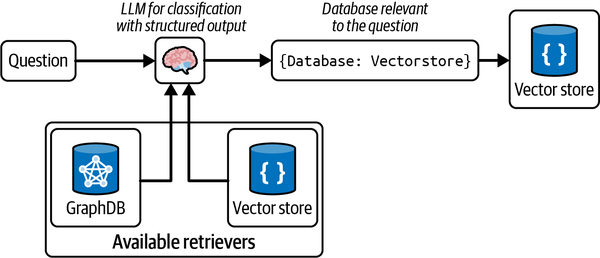


In [54]:
from typing import Literal
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_google_genai import GoogleGenerativeAI
from langchain.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI


class RouteQuery(BaseModel):
    "Route a user query to the most relevant datasource"

    datasource: Literal['python_docs', "js_docs"] = Field(
        ...,
        description="Given a user question, Choose which datasource is most relevant to the question")


# llm = GoogleGenerativeAI(model="gemini-2.0-flash-001",
#                          api_key=GoogleGeminiKey, temperature=0)

# llm = ChatGroq(groq_api_key = os.getenv('GROQ_KEY'),model='llama3-70b-8192',temperature=0)
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001",
                         api_key=GoogleGeminiKey, temperature=0)

structured_llm = llm.with_structured_output(RouteQuery)

system_prompt = """
you are an expert query router that routes user queries to the most relevant datasource based on the question. 

Based on the programming language the question is referring to, route to the most relevant datasource.

"""

prompt = ChatPromptTemplate.from_messages([
    ('system',system_prompt),
    ("human","{query}")
])

router = prompt | structured_llm

In [55]:
question = """Why doesn't the following code work:

from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(["human", "speak in {language}"])
prompt.invoke("french")
"""

result = router.invoke({"query": question})

result.datasource

'python_docs'

In [56]:
question = """
import { ChatOpenAI } from "@langchain/openai";
import { z } from "zod";

const routeQuery = z.object({
  datasource: z.enum(["python_docs", "js_docs"]).describe(`Given a user 
    question, choose which datasource would be most relevant for answering 
    their question`),
}).describe("Route a user query to the most relevant datasource.")
 
"""

result = router.invoke({"query": question})

result.datasource

'js_docs'